# Notebook 2 : Approches ML Classiques

Ce notebook compare différentes représentations textuelles avec des algorithmes de ML classiques :

**Représentations testées :**
- Bag of Words (BOW)
- TF-IDF
- Embeddings pré-entraînés (Sentence-BERT)

**Algorithmes testés :**
- Logistic Regression
- SVM
- Naive Bayes
- Random Forest

**Tâches :**
- Classification de polarité (3 classes : positive, negative, neutral)
- Classification de rating (5 classes : 1-5 étoiles)

## 1. Imports et Configuration

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')

import pickle
import scipy.sparse

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from src.evaluation import evaluate_model, load_results

import json
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

FEATURES_DIR = '../data/precomputed'

## 2. Chargement et Preprocessing des Données

In [27]:
with open(f'{FEATURES_DIR}/train_test_split.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train = splits['X_train']
X_test = splits['X_test']
y_train_pol = splits['y_train_pol']
y_test_pol = splits['y_test_pol']
y_train_rating = splits['y_train_rating']
y_test_rating = splits['y_test_rating']

print(f"Train set : {len(X_train)} reviews")
print(f"Test set  : {len(X_test)} reviews")

Train set : 798328 reviews
Test set  : 199583 reviews


In [28]:
# Vérification des distributions
print(f"Polarité (train) :")
print(y_train_pol.value_counts())
print(f"\nRating (train) :")
print(y_train_rating.value_counts())

Polarité (train) :
polarite
positive    535139
negative    184373
neutral      78816
Name: count, dtype: int64

Rating (train) :
rating
5    369277
4    165862
1    122333
3     78816
2     62040
Name: count, dtype: int64


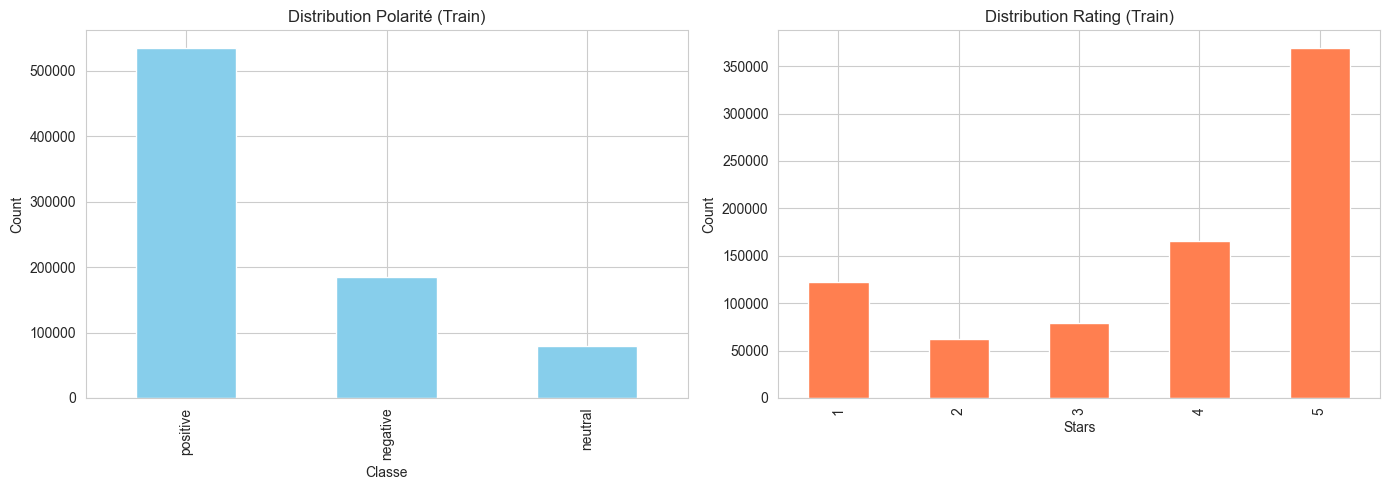

In [29]:
# Visualisation des distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_train_pol.value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution Polarité (Train)')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Count')

y_train_rating.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution Rating (Train)')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [30]:
print(f"Train set : {len(X_train)} reviews")
print(f"Test set  : {len(X_test)} reviews")
print(f"\nTrain polarité distribution :")
print(y_train_pol.value_counts())

Train set : 798328 reviews
Test set  : 199583 reviews

Train polarité distribution :
polarite
positive    535139
negative    184373
neutral      78816
Name: count, dtype: int64


## 5. Approche 1 : Bag of Words (BOW)

Représentation la plus simple : comptage des occurrences de mots.

In [31]:
# Chargement BOW précalculé
X_train_bow = scipy.sparse.load_npz(f'{FEATURES_DIR}/bow_train.npz')
X_test_bow = scipy.sparse.load_npz(f'{FEATURES_DIR}/bow_test.npz')
with open(f'{FEATURES_DIR}/bow_vectorizer.pkl', 'rb') as f:
    bow_vectorizer = pickle.load(f)

print(f"BOW shape: {X_train_bow.shape}")
print(f"Vocabulaire size: {len(bow_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])):.2%}")

BOW shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.28%


### 5.1 BOW + Logistic Regression


 BOW + LogReg
Accuracy:     0.8670
F1-macro:     0.7007
F1-weighted:  0.8513

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84     46093
     neutral       0.51      0.24      0.33     19704
    positive       0.90      0.96      0.93    133786

    accuracy                           0.87    199583
   macro avg       0.75      0.69      0.70    199583
weighted avg       0.85      0.87      0.85    199583



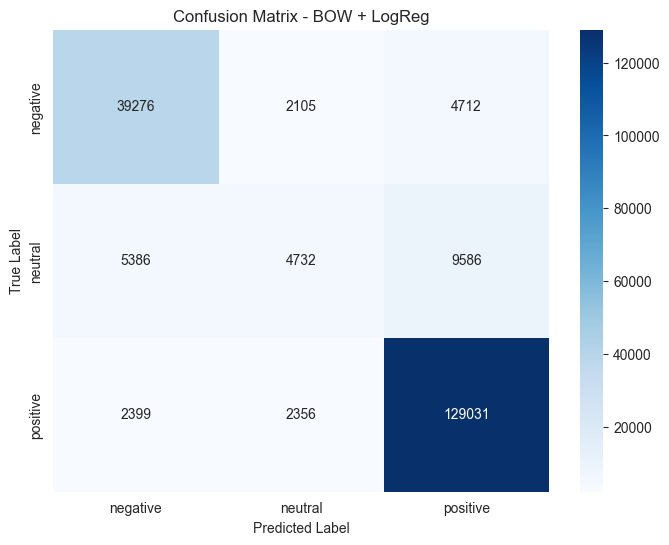

{'model': 'BOW + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.8670027006308153,
 'f1_macro': 0.7006673368467465,
 'f1_weighted': 0.8513182479031657}

In [32]:
lr_bow = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    C=1.0,
)   

lr_bow.fit(X_train_bow, y_train_pol)
evaluate_model(lr_bow, X_test_bow, y_test_pol, "BOW + LogReg")

### 5.2 BOW + SVM


 BOW + SVM
Accuracy:     0.8644
F1-macro:     0.6682
F1-weighted:  0.8393

              precision    recall  f1-score   support

    negative       0.83      0.85      0.84     46093
     neutral       0.58      0.15      0.24     19704
    positive       0.89      0.97      0.93    133786

    accuracy                           0.86    199583
   macro avg       0.76      0.66      0.67    199583
weighted avg       0.84      0.86      0.84    199583



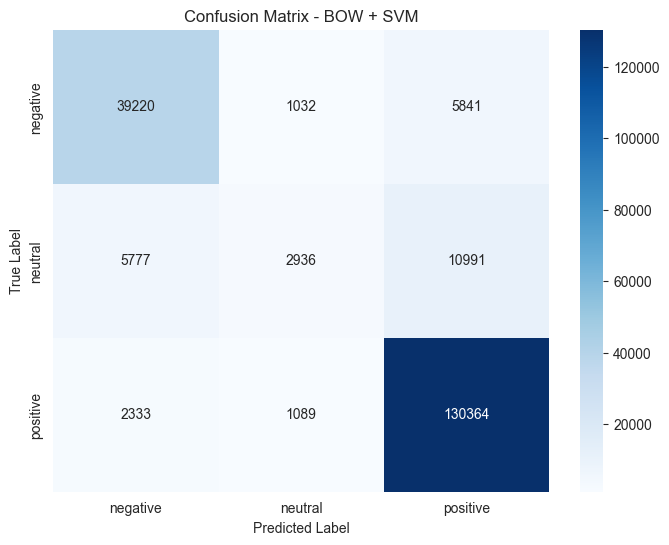

{'model': 'BOW + SVM',
 'type': 'ML Classique',
 'accuracy': 0.8644022787511962,
 'f1_macro': 0.6682287173151611,
 'f1_weighted': 0.8393287841194941}

In [33]:
svm_bow = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_bow.fit(X_train_bow, y_train_pol)
evaluate_model(svm_bow, X_test_bow, y_test_pol, "BOW + SVM")

### 5.3 BOW + Naive Bayes


 BOW + NaiveBayes
Accuracy:     0.7872
F1-macro:     0.6709
F1-weighted:  0.8018

              precision    recall  f1-score   support

    negative       0.72      0.72      0.72     46093
     neutral       0.33      0.53      0.41     19704
    positive       0.93      0.85      0.89    133786

    accuracy                           0.79    199583
   macro avg       0.66      0.70      0.67    199583
weighted avg       0.82      0.79      0.80    199583



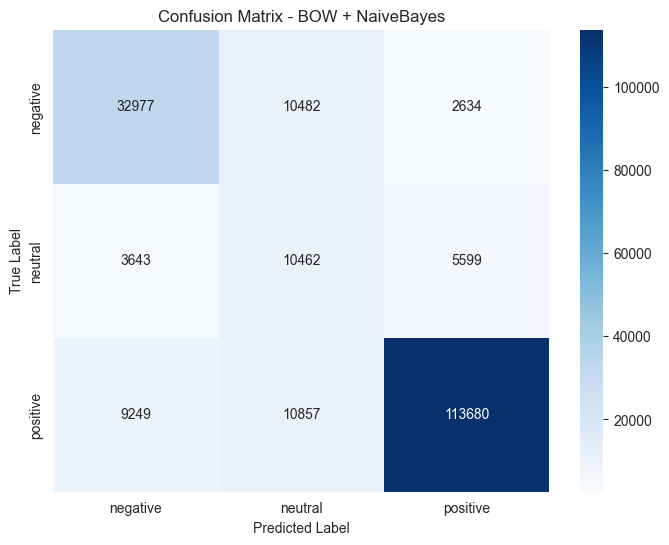

{'model': 'BOW + NaiveBayes',
 'type': 'ML Classique',
 'accuracy': 0.7872363878687062,
 'f1_macro': 0.6708699413865657,
 'f1_weighted': 0.8017750578166118}

In [34]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train_pol)
evaluate_model(nb_bow, X_test_bow, y_test_pol, "BOW + NaiveBayes")

### 5.4 BOW + Random Forest


 BOW + RandomForest
Accuracy:     0.7568
F1-macro:     0.4644
F1-weighted:  0.6948

              precision    recall  f1-score   support

    negative       0.91      0.39      0.54     46093
     neutral       0.00      0.00      0.00     19704
    positive       0.74      0.99      0.85    133786

    accuracy                           0.76    199583
   macro avg       0.55      0.46      0.46    199583
weighted avg       0.71      0.76      0.69    199583



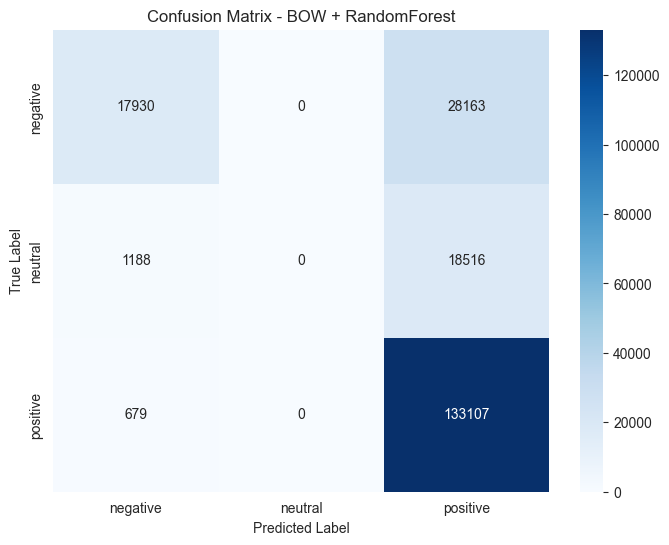

{'model': 'BOW + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.756762850543383,
 'f1_macro': 0.4644042951519875,
 'f1_weighted': 0.6947801447911484}

In [35]:
rf_bow = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20
)
rf_bow.fit(X_train_bow, y_train_pol)
evaluate_model(rf_bow, X_test_bow, y_test_pol, "BOW + RandomForest")

## 6. Approche 2 : TF-IDF

Pondération des mots par leur importance (terme fréquence × inverse document fréquence).

In [36]:
# Chargement TF-IDF précalculé
X_train_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_train.npz')
X_test_tfidf = scipy.sparse.load_npz(f'{FEATURES_DIR}/tfidf_test.npz')
with open(f'{FEATURES_DIR}/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vocabulaire size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2%}")

TF-IDF shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.23%


### 6.1 TF-IDF + Logistic Regression


 TF-IDF + LogReg
Accuracy:     0.8728
F1-macro:     0.7197
F1-weighted:  0.8602

              precision    recall  f1-score   support

    negative       0.83      0.87      0.85     46093
     neutral       0.54      0.29      0.37     19704
    positive       0.91      0.96      0.94    133786

    accuracy                           0.87    199583
   macro avg       0.76      0.70      0.72    199583
weighted avg       0.86      0.87      0.86    199583



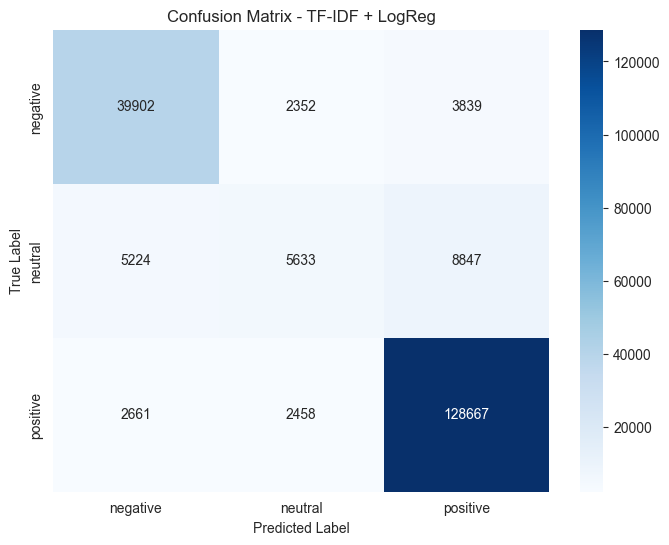

{'model': 'TF-IDF + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.8728298502377457,
 'f1_macro': 0.719684452923874,
 'f1_weighted': 0.8601622610206937}

In [37]:
lr_tfidf = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

lr_tfidf.fit(X_train_tfidf, y_train_pol)
evaluate_model(lr_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + LogReg")

### 6.2 TF-IDF + SVM


 TF-IDF + SVM
Accuracy:     0.8712
F1-macro:     0.6870
F1-weighted:  0.8494

              precision    recall  f1-score   support

    negative       0.82      0.88      0.85     46093
     neutral       0.60      0.18      0.28     19704
    positive       0.90      0.97      0.93    133786

    accuracy                           0.87    199583
   macro avg       0.77      0.68      0.69    199583
weighted avg       0.85      0.87      0.85    199583



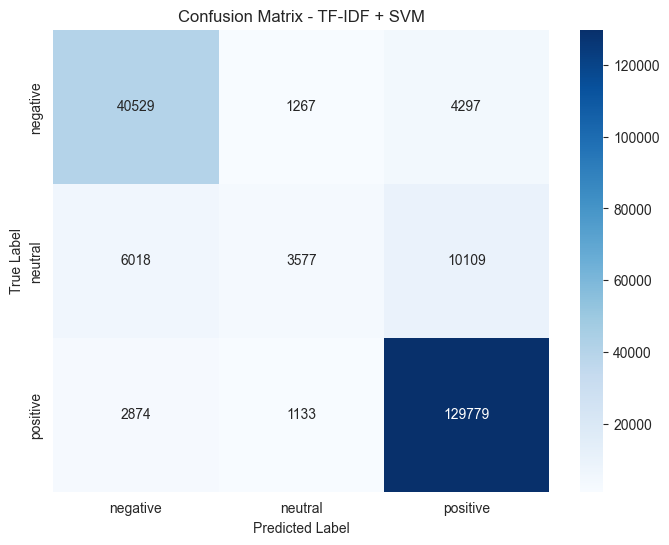

{'model': 'TF-IDF + SVM',
 'type': 'ML Classique',
 'accuracy': 0.8712415386079977,
 'f1_macro': 0.6869938144582038,
 'f1_weighted': 0.8494197460865326}

In [38]:
svm_tfidf = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_tfidf.fit(X_train_tfidf, y_train_pol)
evaluate_model(svm_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + SVM")

### 6.3 TF-IDF + Naive Bayes


 TF-IDF + NaiveBayes
Accuracy:     0.8269
F1-macro:     0.6060
F1-weighted:  0.7957

              precision    recall  f1-score   support

    negative       0.80      0.75      0.77     46093
     neutral       0.46      0.09      0.14     19704
    positive       0.84      0.96      0.90    133786

    accuracy                           0.83    199583
   macro avg       0.70      0.60      0.61    199583
weighted avg       0.80      0.83      0.80    199583



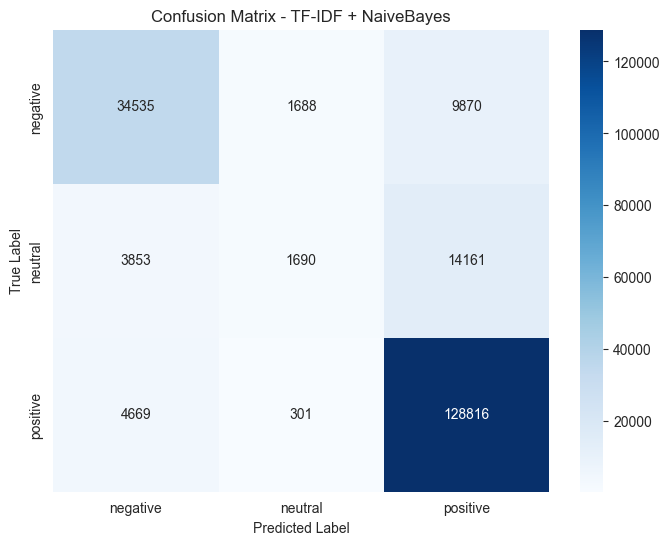

{'model': 'TF-IDF + NaiveBayes',
 'type': 'ML Classique',
 'accuracy': 0.8269291472720622,
 'f1_macro': 0.6060443116922208,
 'f1_weighted': 0.7957043895304273}

In [39]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_pol)
evaluate_model(nb_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + NaiveBayes")

### 6.4 TF-IDF + Random Forest


 TF-IDF + RandomForest
Accuracy:     0.7547
F1-macro:     0.4608
F1-weighted:  0.6918

              precision    recall  f1-score   support

    negative       0.91      0.38      0.53     46093
     neutral       0.00      0.00      0.00     19704
    positive       0.74      1.00      0.85    133786

    accuracy                           0.75    199583
   macro avg       0.55      0.46      0.46    199583
weighted avg       0.70      0.75      0.69    199583



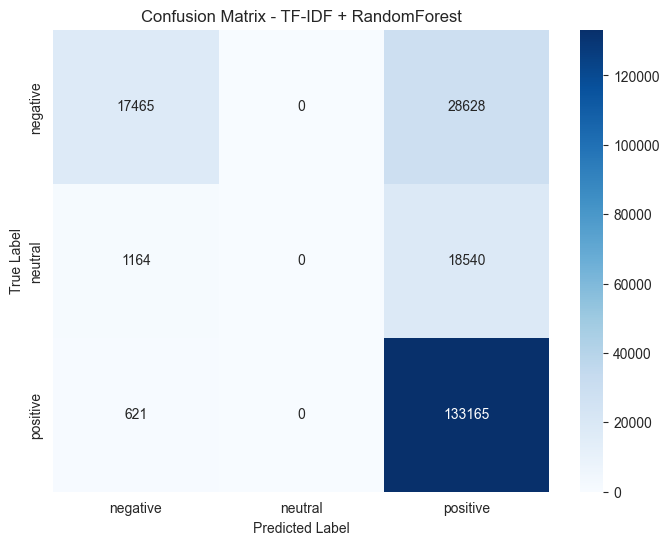

{'model': 'TF-IDF + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.7547235987032964,
 'f1_macro': 0.46080905095907587,
 'f1_weighted': 0.69180190176545}

In [40]:
rf_tfidf = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20
)

rf_tfidf.fit(X_train_tfidf, y_train_pol)
evaluate_model(rf_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + RandomForest")

## 7. Approche 3 : Embeddings Pré-entraînés (Sentence-BERT)

Utilisation de modèles de langage pré-entraînés pour obtenir des représentations denses et sémantiques.

In [49]:
# Embeddings SBERT précalculés (all-MiniLM-L6-v2, 384 dim)
X_train_embeddings = np.load(f'{FEATURES_DIR}/sbert_train.npy')
X_test_embeddings = np.load(f'{FEATURES_DIR}/sbert_test.npy')

print(f"Modèle utilisé : all-MiniLM-L6-v2")
print(f"Dimension des embeddings : {X_train_embeddings.shape[1]}")

Modèle utilisé : all-MiniLM-L6-v2
Dimension des embeddings : 384


In [50]:
# Les embeddings sont déjà chargés
print(f"Train embeddings shape: {X_train_embeddings.shape}")
print(f"Test embeddings shape: {X_test_embeddings.shape}")
print(f"Mémoire : ~{(X_train_embeddings.nbytes + X_test_embeddings.nbytes) / 1e6:.0f} Mo")

Train embeddings shape: (798328, 384)
Test embeddings shape: (199583, 384)
Mémoire : ~1533 Mo


### 7.1 Embeddings + Logistic Regression


 Embeddings + LogReg
Accuracy:     0.8444
F1-macro:     0.6568
F1-weighted:  0.8239

              precision    recall  f1-score   support

    negative       0.79      0.83      0.81     46093
     neutral       0.47      0.17      0.25     19704
    positive       0.88      0.95      0.91    133786

    accuracy                           0.84    199583
   macro avg       0.71      0.65      0.66    199583
weighted avg       0.82      0.84      0.82    199583



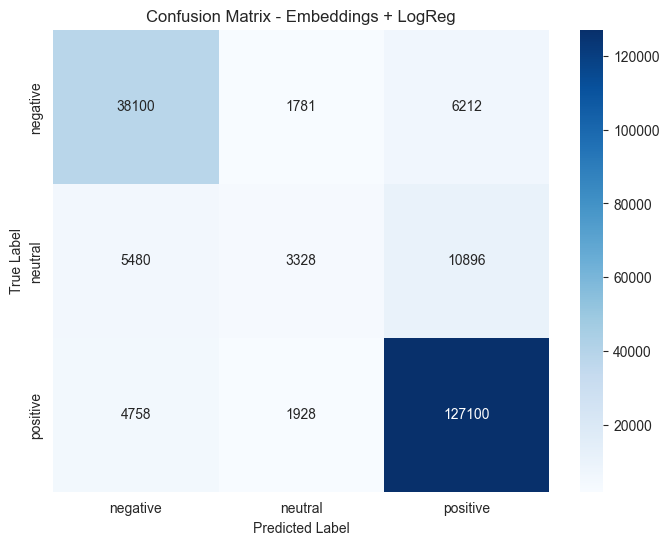

{'model': 'Embeddings + LogReg',
 'type': 'ML Classique',
 'accuracy': 0.8444005751992906,
 'f1_macro': 0.6567509327146942,
 'f1_weighted': 0.8238861909145182}

In [51]:
lr_emb = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

lr_emb.fit(X_train_embeddings, y_train_pol)
evaluate_model(lr_emb, X_test_embeddings, y_test_pol, "Embeddings + LogReg")

### 7.2 Embeddings + SVM


 Embeddings + SVM
Accuracy:     0.8424
F1-macro:     0.6039
F1-weighted:  0.8068

              precision    recall  f1-score   support

    negative       0.77      0.84      0.81     46093
     neutral       0.56      0.05      0.09     19704
    positive       0.87      0.96      0.91    133786

    accuracy                           0.84    199583
   macro avg       0.73      0.62      0.60    199583
weighted avg       0.82      0.84      0.81    199583



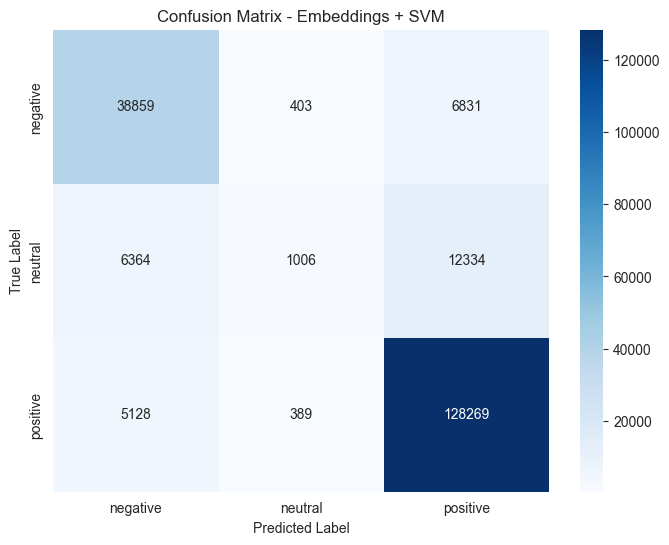

{'model': 'Embeddings + SVM',
 'type': 'ML Classique',
 'accuracy': 0.8424264591673639,
 'f1_macro': 0.6038802058591121,
 'f1_weighted': 0.8068375487552013}

In [52]:
svm_emb = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE
)

svm_emb.fit(X_train_embeddings, y_train_pol)
evaluate_model(svm_emb, X_test_embeddings, y_test_pol, "Embeddings + SVM")

### 7.3 Embeddings + Random Forest


 Embeddings + RandomForest
Accuracy:     0.8091
F1-macro:     0.5417
F1-weighted:  0.7636

              precision    recall  f1-score   support

    negative       0.79      0.70      0.74     46093
     neutral       0.70      0.00      0.00     19704
    positive       0.81      0.97      0.88    133786

    accuracy                           0.81    199583
   macro avg       0.77      0.56      0.54    199583
weighted avg       0.80      0.81      0.76    199583



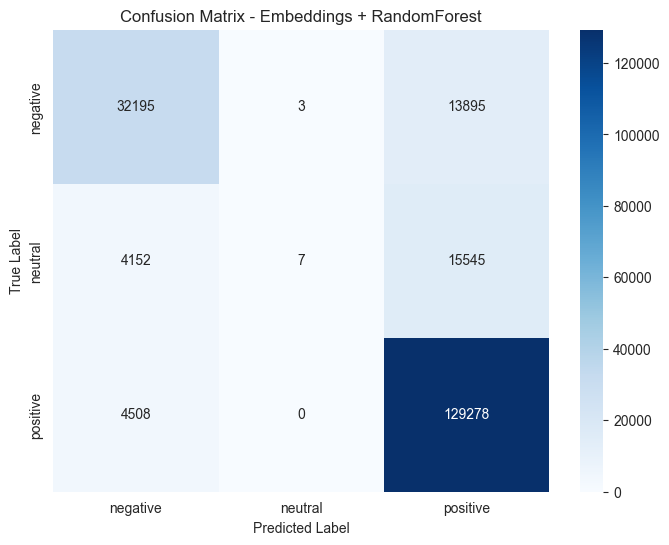

{'model': 'Embeddings + RandomForest',
 'type': 'ML Classique',
 'accuracy': 0.809086946283,
 'f1_macro': 0.5417359261816835,
 'f1_weighted': 0.7636287486386746}

In [53]:
rf_emb = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20,
)

rf_emb.fit(X_train_embeddings, y_train_pol)
evaluate_model(rf_emb, X_test_embeddings, y_test_pol, "Embeddings + RandomForest")

## 8. Comparaison des Résultats

In [54]:
results_df = load_results()
results_df = results_df.sort_values('accuracy', ascending=False)

print("\n" + results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\n Meilleur modèle : {best_model['model']}")
print(f"   Accuracy: {best_model['accuracy']:.4f}")
print(f"   F1-macro: {best_model['f1_macro']:.4f}")


                    model         type  accuracy  f1_macro  f1_weighted
          TF-IDF + LogReg ML Classique  0.872830  0.719684     0.860162
             TF-IDF + SVM ML Classique  0.871242  0.686994     0.849420
             BOW + LogReg ML Classique  0.867003  0.700667     0.851318
                BOW + SVM ML Classique  0.864402  0.668229     0.839329
      Embeddings + LogReg ML Classique  0.844401  0.656751     0.823886
         Embeddings + SVM ML Classique  0.842426  0.603880     0.806838
      TF-IDF + NaiveBayes ML Classique  0.826929  0.606044     0.795704
Embeddings + RandomForest ML Classique  0.809087  0.541736     0.763629
         BOW + NaiveBayes ML Classique  0.787236  0.670870     0.801775
       BOW + RandomForest ML Classique  0.756763  0.464404     0.694780
    TF-IDF + RandomForest ML Classique  0.754724  0.460809     0.691802

 Meilleur modèle : TF-IDF + LogReg
   Accuracy: 0.8728
   F1-macro: 0.7197


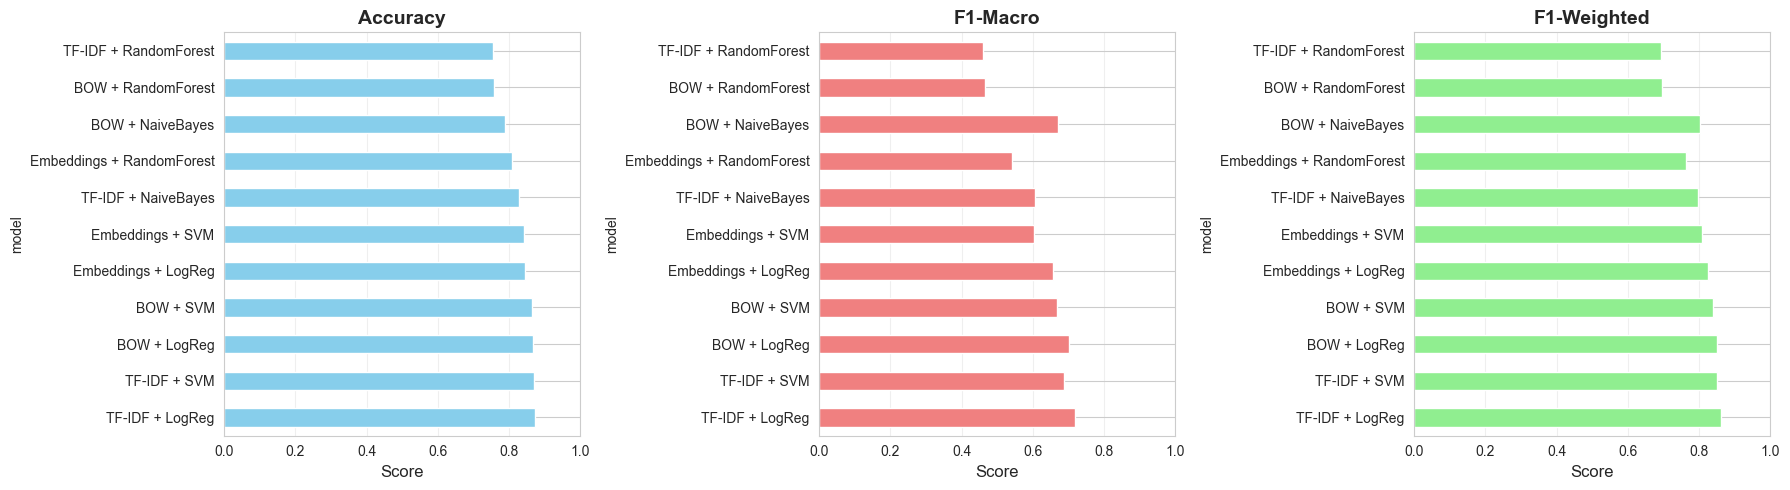


Graphique sauvegardé : ../results/ml_classique_comparison.png


In [55]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
results_df.plot(x='model', y='accuracy', kind='barh', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# F1-macro
results_df.plot(x='model', y='f1_macro', kind='barh', ax=axes[1], legend=False, color='lightcoral')
axes[1].set_title('F1-Macro', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

# F1-weighted
results_df.plot(x='model', y='f1_weighted', kind='barh', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-Weighted', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score', fontsize=12)
axes[2].set_xlim([0, 1])
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ml_classique_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegardé : ../results/ml_classique_comparison.png")

## 9. Sauvegarde des Résultats et Modèles

In [56]:
with open('../models/tfidf_svm.pkl', 'wb') as f:
    pickle.dump(svm_tfidf, f)

print("Modèle TF-IDF sauvegardé : ../models/tfidf_*")

# Embeddings model
with open('../models/embeddings_svm.pkl', 'wb') as f:
    pickle.dump(svm_emb, f)

print("Modèle Embeddings sauvegardé : ../models/embeddings_svm.pkl")

# Sauvegarder les méta-données
metadata = {
    'best_model': best_model['model'],
    'best_accuracy': float(best_model['accuracy']),
    'best_f1_macro': float(best_model['f1_macro']),
    'embedding_model': 'all-MiniLM-L6-v2',
    'train_size': len(X_train),
    'test_size': len(X_test),
    'random_state': RANDOM_STATE
}

with open('../results/ml_classique_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Métadonnées sauvegardées : ../results/ml_classique_metadata.json")

Modèle TF-IDF sauvegardé : ../models/tfidf_*
Modèle Embeddings sauvegardé : ../models/embeddings_svm.pkl
Métadonnées sauvegardées : ../results/ml_classique_metadata.json
